### what this notebook does?
- calculates the NOvA oscillation probabilities.
- cross checks two different engines, one from V0.7.0 and one from V0.8.0
- calculates the probability conservation.

In [14]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt 

from nuosclab import ExplorerConfig, compute_curves

In [15]:
## physics calculation/plot for the nova experiment.
config = ExplorerConfig(
    experiment="NOvA",
    engine="numpy_ref",
    antineutrino=False,
    n_points=400,
)

In [16]:
curves = compute_curves(config)
##finds the nova preset and creates 400 evenly space energy.
##from the engines.py, get teh numpy_ref, which sends all the
## parameters of teh experimetn to that engine.
##computes the probability and results in curve.

In [17]:
print(curves.energy_gev.shape) #prints the type of array(1D)
print(curves.live.shape) #prints the type of array(3D)
#curves.live uses PMNS and NSI values in 'config', this is from core.py
print(curves.preset)

(400,)
(400, 3, 3)
ExperimentPreset(name='NOvA', L_km=810, rho_gcc=2.79, E_range=(0.3, 5.0), E_peak=1.9)


In [18]:
energy = curves.energy_gev

p_mu_to_e = curves.live[:, 0, 1]## first to last energy, final, initial
p_mu_to_mu = curves.live[:, 1, 1]
# 0 -> electron
# 1 -> muon
## initial flavor muon to  final flavor electron. (appereance)
## or initial flavor muon to final flavor muon. (survival)

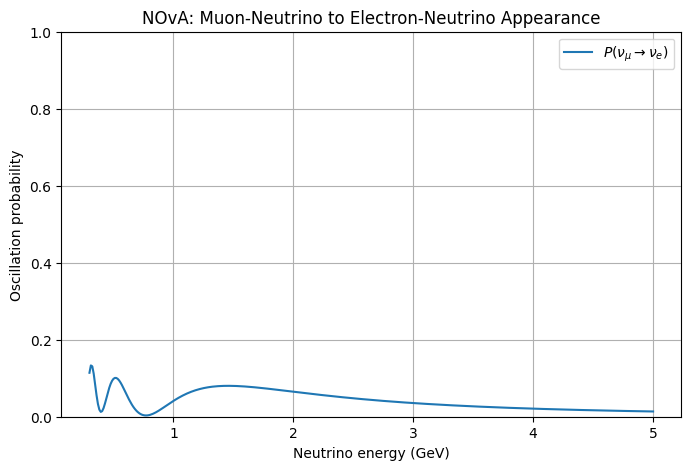

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    energy,
    p_mu_to_e,
    label = r"$P(\nu_\mu \rightarrow \nu_e)$",
)

plt.xlabel("Neutrino energy (GeV)")
plt.ylabel("Oscillation probability")
plt.title("NOvA: Muon-Neutrino to Electron-Neutrino Appearance")
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

## Graph meaning:
- horizontal axis represents the energy.
- vertical axis represents the probability which should be 0 <= P <= 1.

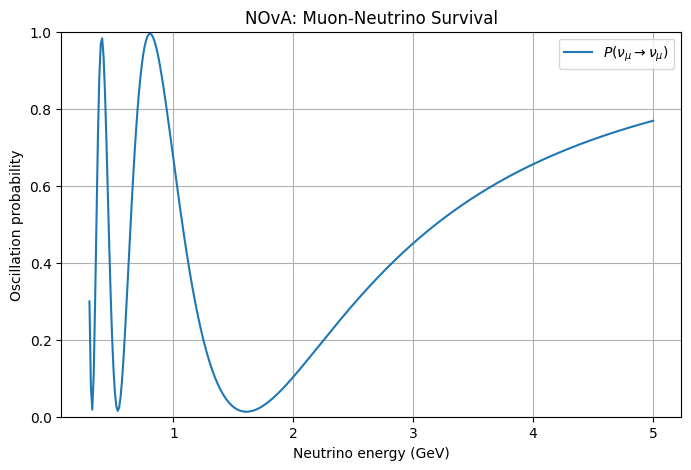

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    energy,
    p_mu_to_mu,
    label=r"$P(\nu_\mu \rightarrow \nu_\mu)$",
)

plt.xlabel("Neutrino energy (GeV)")
plt.ylabel("Oscillation probability")
plt.title("NOvA: Muon-Neutrino Survival")
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

### How to interpret the dip in the plots?
- A dip in $P(\nu_\mu \rightarrow \nu_\mu)$ means that the muon neutrinos at that energy level have high probability of changing into other flavours before reaching the detector.

In [ ]:
## finding the numerical dip location.

dip_index = np.argmin(p_mu_to_mu)
# np.argmin() returns the index containing minimum value.
# physical meaning is this identifies where the model identifies
# strongest muon neutrino dissappereance and prints using the function
# below.

dip_energy = energy[dip_index]
dip_probability = p_mu_to_mu[dip_index] #probability at at minimum energy.


print(f"Deepest survival dip: {dip_energy:.3f} GeV")
print(f"Minimum survival probability: {dip_probability:.4f}")

Deepest survival dip: 1.608 GeV
Minimum survival probability: 0.0130


### Using the nufast engine now.

In [23]:
nufast_config = ExplorerConfig(
    experiment="NOvA",
    engine="nufast",
    antineutrino=False,
    n_points=400,
    include_standard=False,
    include_nominal=False,
)

nufast_curves = compute_curves(nufast_config)

nufast_p_mu_to_e = nufast_curves.live[:, 0, 1]
nufast_p_mu_to_mu = nufast_curves.live[:, 1, 1]

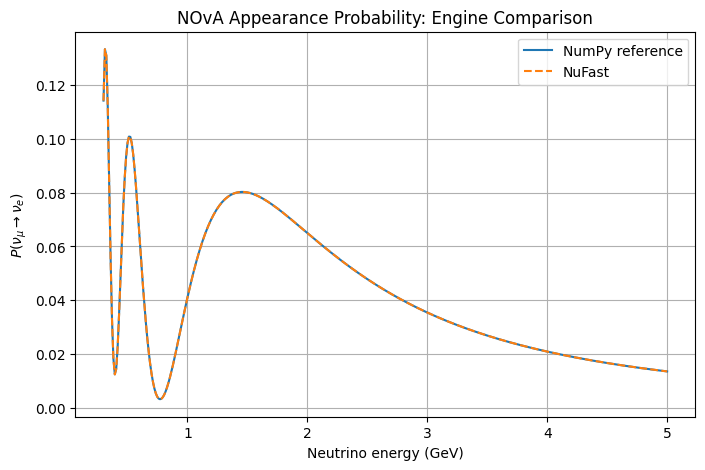

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    energy,
    p_mu_to_e,
    label="NumPy reference",
)

plt.plot(
    energy,
    nufast_p_mu_to_e,
    linestyle="--",
    label="NuFast",
)

plt.xlabel("Neutrino energy (GeV)")
plt.ylabel(r"$P(\nu_\mu \rightarrow \nu_e)$")
plt.title("NOvA Appearance Probability: Engine Comparison")
plt.grid()
plt.legend()
plt.show()

In [25]:
appearance_difference = np.abs(
    p_mu_to_e - nufast_p_mu_to_e
) ## taking the absolute value of the difference.

maximum_difference = np.max(appearance_difference) ## finding the maximum difference in the wholw energy range.

print("Maximum appearance-probability difference:", maximum_difference)

Maximum appearance-probability difference: 8.969270589520573e-06


So far, I have calculated $P(\nu_ \mu \rightarrow \nu_e)$, $P(\nu_ \mu \rightarrow \nu_ \mu)$. However, there is a third possible final flavor: $P(\nu_ \mu \rightarrow \nu_ \tau)$. 

Saying this, we also know the probability is never greater than 1, so using this we can actually calculate the probability of tau neutrino appereance using the formula:

$P$ = $P(\nu_ \mu \rightarrow \nu_e)$ + $P(\nu_ \mu \rightarrow \nu_ \mu)$ + $P(\nu_ \mu \rightarrow \nu_ \tau)$ = 1

But, there might be few errors, or might be some 3+1, neutrinos that we have not talked in our code. So, the below code blocks explain where the missing muon probability goes.

In [26]:
p_mu_to_tau = curves.live[:, 2, 1] ## 0, 1, 2 -> electron, muon, tau
probability_sum = (p_mu_to_e + p_mu_to_mu +p_mu_to_tau)
## this should result in 1, but to avoid any errors,lets calculate the maximum conservation errors.

maximum_conservation_error = np.max(np.abs(probability_sum - 1))
## this calculates the absolute value for the maximum probability, which should in theory be always 1.

print("maximum probability conservation error: ", maximum_conservation_error)


maximum probability conservation error:  1.9984014443252818e-15


### Inspecting all three flavours at the muon survival dip.
- from the above cells, we found the E<sub>dip</sub> = 1.608 GeV, now we use the same index for the array to find the probability of muon to muon,electron and tau, and then calculate the total energy at that energy, and that dip index.

In [27]:
print("Energy: " ,energy[dip_index], " GeV")

print("Muon to Muon ", p_mu_to_mu[dip_index])
print("Muon to Electron ", p_mu_to_e[dip_index])
print("Muon to Tau ", p_mu_to_tau[dip_index])

print("Total survival: ", probability_sum[dip_index])

Energy:  1.6075187969924811  GeV
Muon to Muon  0.012957975223505796
Muon to Electron  0.07827990608596255
Muon to Tau  0.9087621186905319
Total survival:  1.0000000000000002


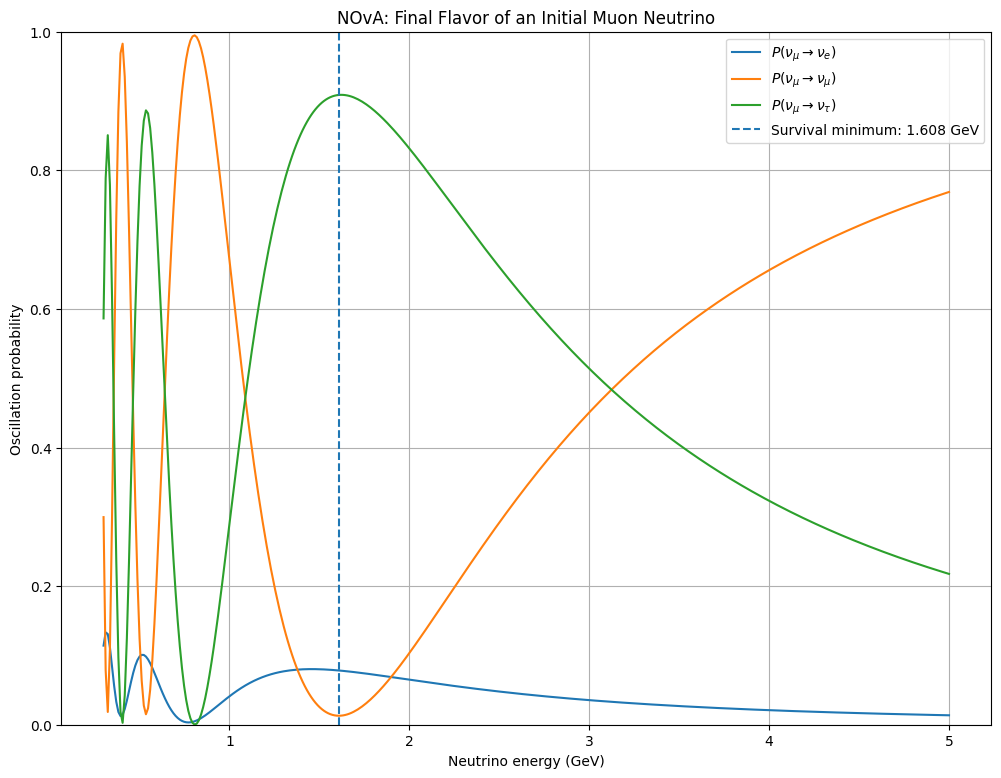

In [30]:
plt.figure(figsize=(12, 9))

plt.plot(
    energy,
    p_mu_to_e,
    label=r"$P(\nu_\mu \rightarrow \nu_e)$",
)

plt.plot(
    energy,
    p_mu_to_mu,
    label=r"$P(\nu_\mu \rightarrow \nu_\mu)$",
)

plt.plot(
    energy,
    p_mu_to_tau,
    label=r"$P(\nu_\mu \rightarrow \nu_\tau)$",
)

plt.axvline(
    dip_energy,
    linestyle="--",
    label=f"Survival minimum: {dip_energy:.3f} GeV",
)

plt.xlabel("Neutrino energy (GeV)")
plt.ylabel("Oscillation probability")
plt.title("NOvA: Final Flavor of an Initial Muon Neutrino")
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

#### The above plote answers, at each energy, how is the original muon-neutrino state distributed among electron, muon, and tau flavors after 810 km.

- for example, at beam peak 1.608 GeV, the $P(\nu_ \mu \rightarrow \nu_e)$ is around 0.1 and $P(\nu_ \mu \rightarrow \nu_ \mu)$ is around 0.05  and $P(\nu_ \mu \rightarrow \nu_ \tau)$ is around 0.85, which makes the total sum to be 1, which should be the maximum probability, which alines with the probability conservation.

- from this we can get the general idea of what this plot does.


## why does the dip occurs at 1.608 GeV?
- The full NuOscLab calculation uses three flavors, matter effects, and the complete PMNS Hamiltonian.

But we can approximately understand the location of the dip using the simpler two-flavor survival formula:
$$
P(\nu_\mu \rightarrow \nu_e)
=
\sin^2(2\theta)\,
\sin^2\left(1.27\frac{\Delta m^2 L}{E}\right)
$$

- So, If no flavor transformation happened, the survival probability would be: 1.
- $\theta$ is one of the PMNS mixing angle, for the 23, it controls mixing between muon and tau.
- the nuosclab uses $\theta$ = 49.2 
- using all the default values in the PMNSparams,we can approximate the first dip at 1.6 GeV.